In [2]:
# ShadowGraph Data Review (`200imgs` + `morphocluster-free-number-of-clusters-200imgs`)

# 本 notebook 用于会议汇报，目标是：

# 1. 全量盘点两个目录中的数据文件（尽可能利用所有文件类型）
# 2. 核验主表、JSON、YOLO 导出之间的一致性
# 3. 分析类别不均衡、49簇到7类映射、形态特征、每帧检测数量
# 4. 深入分析 `subclusters/`（类内二级聚类）
# 5. 给出建模建议（supervised / semi-supervised clustering）

# > 建议：从上到下顺序执行。

In [4]:
# 如果环境还没安装分析依赖，先执行本单元
# !pip install -q pandas numpy matplotlib seaborn pyyaml

In [5]:
from pathlib import Path
import os
import re
import json
import csv
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

ROOT = Path(r"e:/research/ShadowGraph")
DIR_A = ROOT / "data/200imgsResults_annotation_results/200imgsResults_annotation_results"
DIR_B = ROOT / "data/morphocluster-free-number-of-clusters-200imgs"

# 主数据文件
corrected_csv = DIR_A / "200imgsResults_annotation_corrected.csv"
ann_dir = DIR_A / "200imgsResults_annotation"
det_csv = ann_dir / "detections.csv"
mosaic_csv = ann_dir / "mosaic_annotations.csv"
run_json = ann_dir / "run_parameters.json"
annotation_json = DIR_A / "200imgsResults_annotation.json"
yolo_labels_big_txt = DIR_A / "200imgsResults_yolo_labels.txt"

# YOLO 数据集导出目录
yolo_dir = DIR_A / "200imgsResults_yolo_dataset"
yolo_yaml = yolo_dir / "data.yaml"
yolo_classes = yolo_dir / "classes.txt"
yolo_labels_dir = yolo_dir / "labels"

print('ROOT:', ROOT)
print('DIR_A exists:', DIR_A.exists())
print('DIR_B exists:', DIR_B.exists())

ROOT: e:\research\ShadowGraph
DIR_A exists: True
DIR_B exists: True


In [6]:
# 1) 全量文件盘点（尽可能利用所有文件）

def collect_files(base: Path):
    rows = []
    for p in base.rglob('*'):
        if p.is_file():
            rel = p.relative_to(base)
            rows.append({
                'base': base.name,
                'relative_path': str(rel).replace('\\', '/'),
                'ext': p.suffix.lower() if p.suffix else '<no_ext>',
                'size_kb': round(p.stat().st_size / 1024, 2),
                'parent': str(rel.parent).replace('\\', '/'),
            })
    return pd.DataFrame(rows)

files_a = collect_files(DIR_A)
files_b = collect_files(DIR_B)
files_all = pd.concat([files_a, files_b], ignore_index=True)

print('Total files in DIR_A:', len(files_a))
print('Total files in DIR_B:', len(files_b))
print('Total files (A+B):', len(files_all))

print('\nBy extension:')
display(files_all.groupby('ext').size().sort_values(ascending=False).rename('count').to_frame())

print('\nTop folders by file count:')
display(files_all.groupby(['base', 'parent']).size().sort_values(ascending=False).head(20).rename('count').to_frame())

print('\nSample files:')
display(files_all.sample(min(20, len(files_all)), random_state=42).sort_values(['base', 'relative_path']))

Total files in DIR_A: 491
Total files in DIR_B: 397
Total files (A+B): 888

By extension:


,count
ext,
.png,246
.csv,219
.txt,202
.jpg,200
.json,10
.zip,10
.yaml,1



Top folders by file count:


count
base                                          parent                                                   
200imgsResults_annotation_results             200imgsResults_annotations_per_image                  200
morphocluster-free-number-of-clusters-200imgs 200samples                                            200
200imgsResults_annotation_results             200imgsResults_yolo_dataset/labels                    200
morphocluster-free-number-of-clusters-200imgs 200imgsResults_annotation                              83
200imgsResults_annotation_results             200imgsResults_annotation                              83
morphocluster-free-number-of-clusters-200imgs subclusters/Detritus___Unsharp_Organisms_annota...     64
                                              subclusters/Cladoceramorpha_annotation                 21
                                              subclusters                                             7
200imgsResults_annotation_results             .                                                       6
morphocluster-free-number-of-clusters-200imgs subclusters/Copepoda_annotation                         6
                                              subclusters/Leptodora_kindtii_annotation                4
                                              subclusters/Rotifera_annotation                         4
                                              subclusters/Plant_or_Algae_annotation                   4
                                              subclusters/Unidentified_Organism_annotation            4
200imgsResults_annotation_results             200imgsResults_yolo_dataset                             2


Sample files:


,base,relative_path,ext,size_kb,parent
39,200imgsResults_annotation_results,200imgsResults_annotation/cluster_12_mosaic.png,.png,107.90,200imgsResults_annotation
72,200imgsResults_annotation_results,200imgsResults_annotation/cluster_45_mosaic.png,.png,85.88,200imgsResults_annotation
141,200imgsResults_annotation_results,200imgsResults_annotations_per_image/RCNHSha_2...,.csv,0.71,200imgsResults_annotations_per_image
280,200imgsResults_annotation_results,200imgsResults_annotations_per_image/RCNHSha_2...,.csv,5.55,200imgsResults_annotations_per_image
342,200imgsResults_annotation_results,200imgsResults_yolo_dataset/labels/RCNHSha_202...,.txt,0.45,200imgsResults_yolo_dataset/labels
417,200imgsResults_annotation_results,200imgsResults_yolo_dataset/labels/RCNHSha_202...,.txt,1.56,200imgsResults_yolo_dataset/labels
434,200imgsResults_annotation_results,200imgsResults_yolo_dataset/labels/RCNHSha_202...,.txt,1.78,200imgsResults_yolo_dataset/labels
507,morphocluster-free-number-of-clusters-200imgs,200imgsResults_annotation/cluster_05_mosaic.png,.png,330.60,200imgsResults_annotation
530,morphocluster-free-number-of-clusters-200imgs,200imgsResults_annotation/cluster_17_mosaic.png,.png,162.64,200imgsResults_annotation
536,morphocluster-free-number-of-clusters-200imgs,200imgsResults_annotation/cluster_23_mosaic.png,.png,73.79,200imgsResults_annotation


In [7]:
# 2) 主表加载 + 基础一致性核验

df_corr = pd.read_csv(corrected_csv)
df_det = pd.read_csv(det_csv)
df_mosaic = pd.read_csv(mosaic_csv)

with open(run_json, 'r', encoding='utf-8') as f:
    run = json.load(f)
with open(annotation_json, 'r', encoding='utf-8') as f:
    ann = json.load(f)

summary = {
    'corrected_rows': len(df_corr),
    'detections_rows': len(df_det),
    'mosaic_rows': len(df_mosaic),
    'unique_frames_in_corrected': df_corr['frame'].nunique(),
    'run.total_detections': run.get('results', {}).get('total_detections'),
    'run.n_clusters': run.get('results', {}).get('n_clusters'),
    'run.feature_dim': run.get('results', {}).get('feature_dim'),
    'json.imageWidth': ann.get('imageWidth'),
    'json.imageHeight': ann.get('imageHeight'),
}

display(pd.Series(summary, name='value').to_frame())

# ID 对齐检查（object_id vs detection_id）
set_det_ids = set(df_det['object_id'].astype(int).tolist())
set_corr_ids = set(df_corr['detection_id'].astype(int).tolist())
set_mosaic_ids = set(df_mosaic['detection_id'].astype(int).tolist())

id_check = {
    'det_ids_count': len(set_det_ids),
    'corr_ids_count': len(set_corr_ids),
    'mosaic_ids_count': len(set_mosaic_ids),
    'corr_minus_det': len(set_corr_ids - set_det_ids),
    'det_minus_corr': len(set_det_ids - set_corr_ids),
    'mosaic_minus_det': len(set_mosaic_ids - set_det_ids),
}

display(pd.Series(id_check, name='value').to_frame())

,value
corrected_rows,9583
detections_rows,9583
mosaic_rows,9583
unique_frames_in_corrected,200
run.total_detections,9583
run.n_clusters,49
run.feature_dim,512
json.imageWidth,1920
json.imageHeight,1080


,value
det_ids_count,9583
corr_ids_count,9583
mosaic_ids_count,9583
corr_minus_det,0
det_minus_corr,0
mosaic_minus_det,0


In [11]:
# 3) 类别分布 + 状态分布（不均衡问题）

class_counts = (
    df_corr['class_name']
    .value_counts()
    .rename_axis('class_name')
    .reset_index(name='count')
)
class_counts['ratio_%'] = (class_counts['count'] / class_counts['count'].sum() * 100).round(3)

display(class_counts)

# plt.figure(figsize=(12, 6))
# sns.barplot(data=class_counts, x='class_name', y='count', color='#4C78A8')
# plt.xticks(rotation=35, ha='right')
# plt.title('Class Distribution (count)')
# plt.tight_layout()
# plt.show()

# status_counts = df_corr['status'].value_counts().rename_axis('status').reset_index(name='count')
# status_counts['ratio_%'] = (status_counts['count'] / status_counts['count'].sum() * 100).round(3)
# display(status_counts)

# # 每类中 relabelled 比例（更稳健：避免 MultiIndex 列名问题）
# status_pivot = (
#     df_corr
#     .assign(is_relabelled=(df_corr['status'].str.lower() == 'relabelled').astype(int))
#     .groupby('class_name', as_index=False)
#     .agg(relabelled=('is_relabelled', 'sum'), total=('is_relabelled', 'count'))
# )
# status_pivot['relabel_ratio_%'] = (status_pivot['relabelled'] / status_pivot['total'] * 100).round(3)
# status_pivot = status_pivot.sort_values('relabel_ratio_%', ascending=False)
# display(status_pivot)

,class_name,count,ratio_%
0,Detritus / Unsharp Organisms,9077,94.720
1,Cladoceramorpha,420,4.383
2,Copepoda,67,0.699
3,Unidentified_Organism,12,0.125
4,Rotifera,4,0.042
5,Leptodora kindtii,2,0.021
6,Plant_or_Algae,1,0.010


,count,mean,std,min,1%,5%,50%,95%,99%,max
area,9583.0,3272.807993,2748.282538,1200.0000,1210.000000,1255.000000,2249.000000,8413.800000,13321.260000,45126.000000
bbox_area,9583.0,9493.640718,14166.657465,1519.0000,1785.820000,2070.000000,4794.000000,30685.500000,69263.660000,257222.000000
w,9583.0,87.258166,55.199285,21.0000,32.000000,39.000000,71.000000,185.000000,276.180000,1934.000000
h,9583.0,89.089429,55.817641,24.0000,33.000000,40.000000,72.000000,194.000000,293.000000,710.000000
solidity,9583.0,0.716674,0.155762,0.2002,0.324374,0.429620,0.732100,0.943800,0.967736,0.981000
eccentricity,9583.0,0.835345,0.134790,0.1560,0.381164,0.565700,0.875800,0.975800,0.988336,0.999200
focus_score,9583.0,18.339589,8.455244,5.1350,8.845782,10.675380,16.699000,31.239940,45.459596,472.978500
quality_score,9583.0,0.343323,0.048655,0.1824,0.237746,0.266200,0.343300,0.426390,0.465536,0.861300
aspect_ratio,9583.0,1.096381,0.555817,0.1200,0.328915,0.458641,0.984733,2.128151,2.954727,14.541353


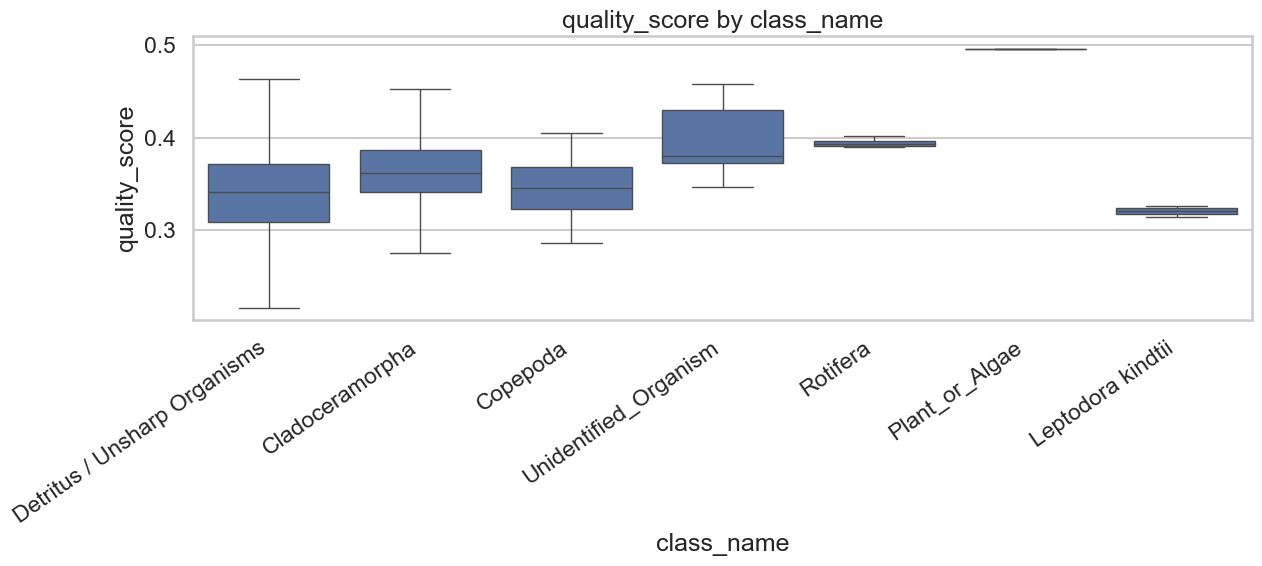

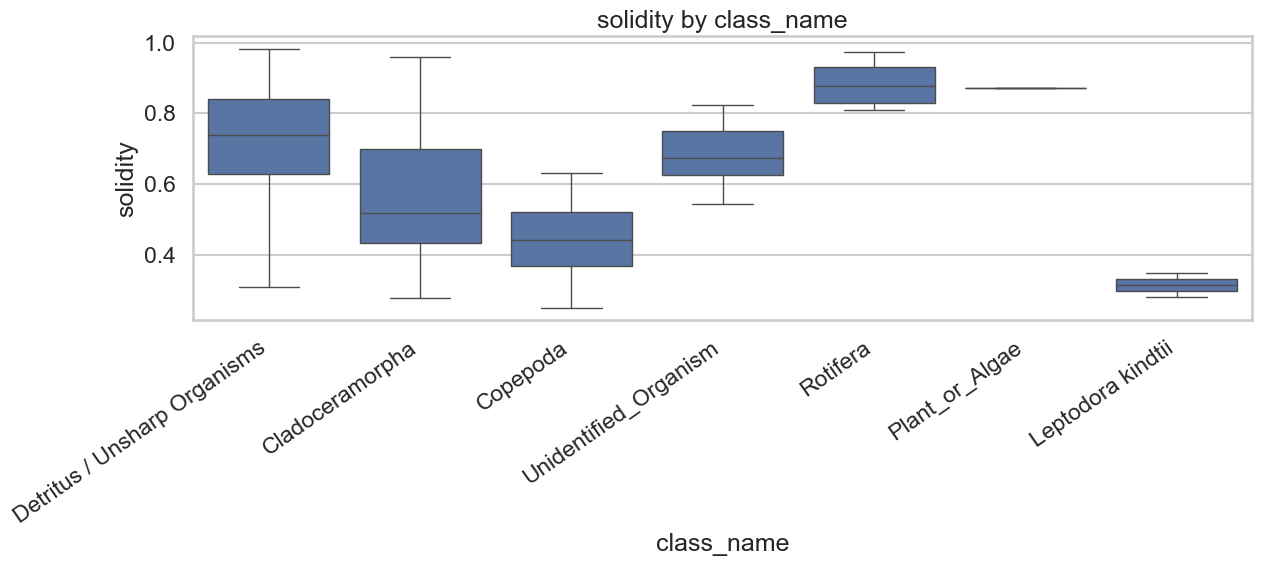

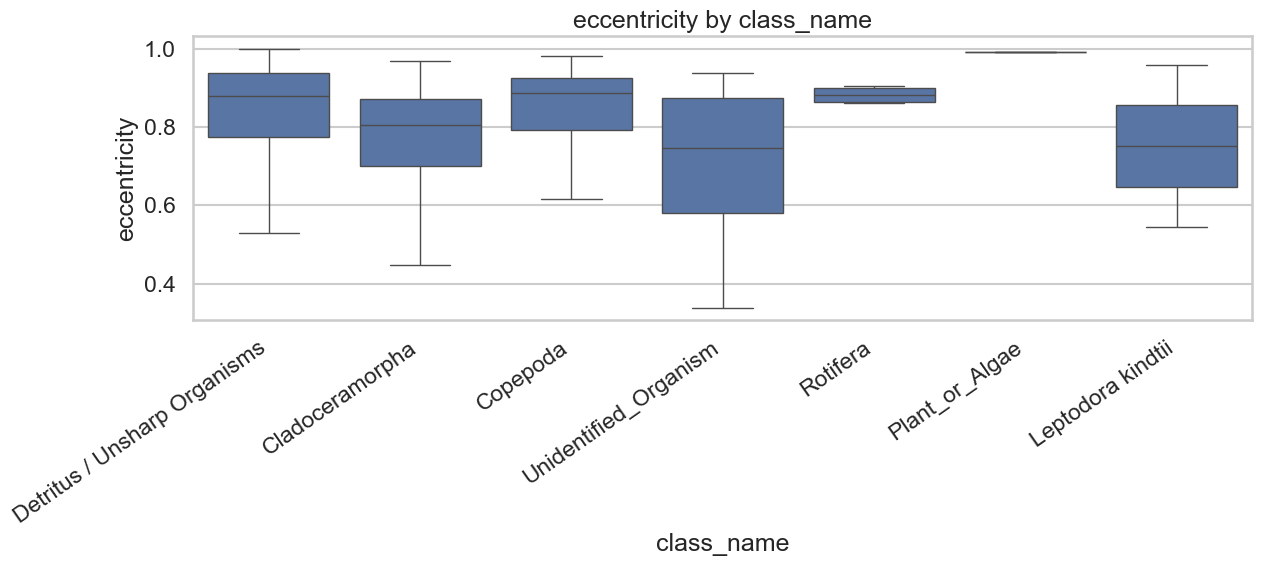

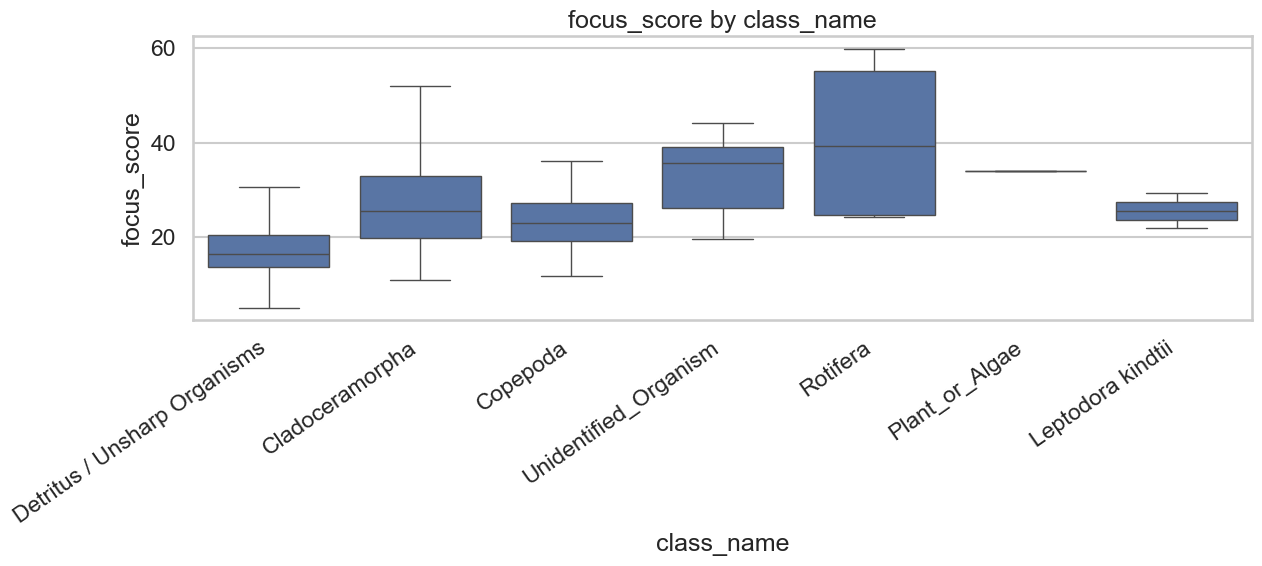

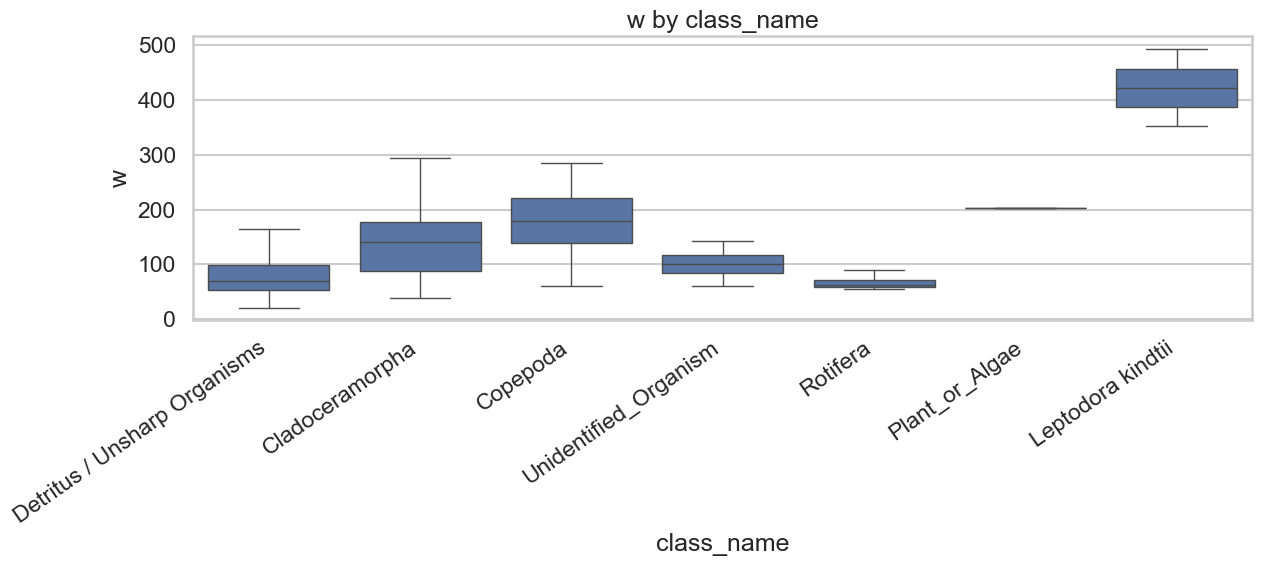

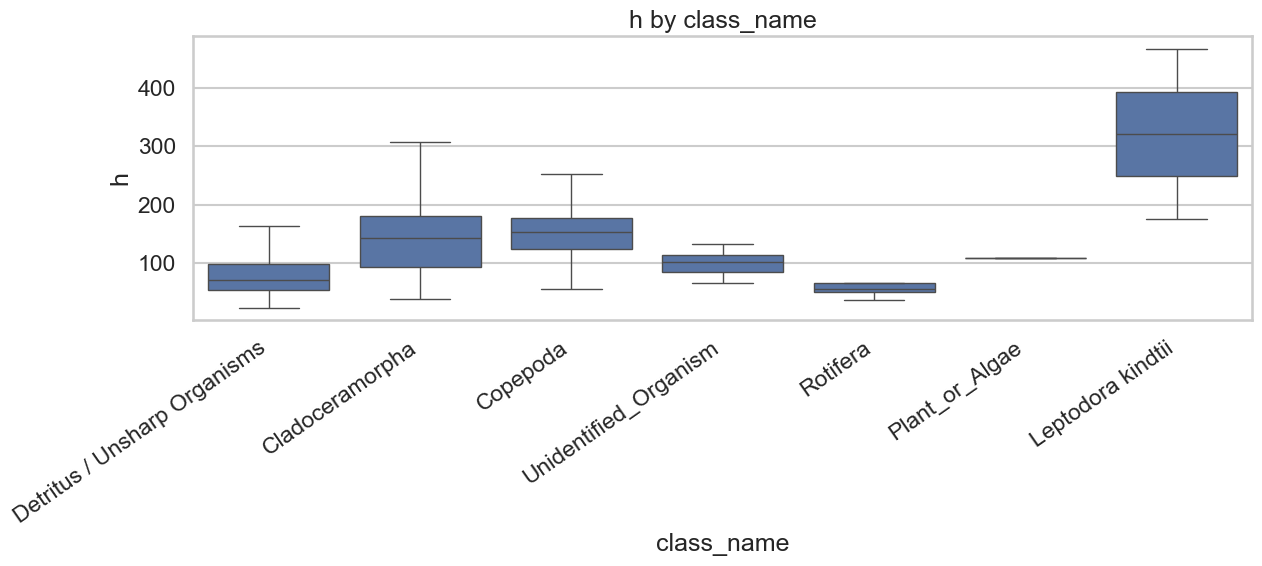

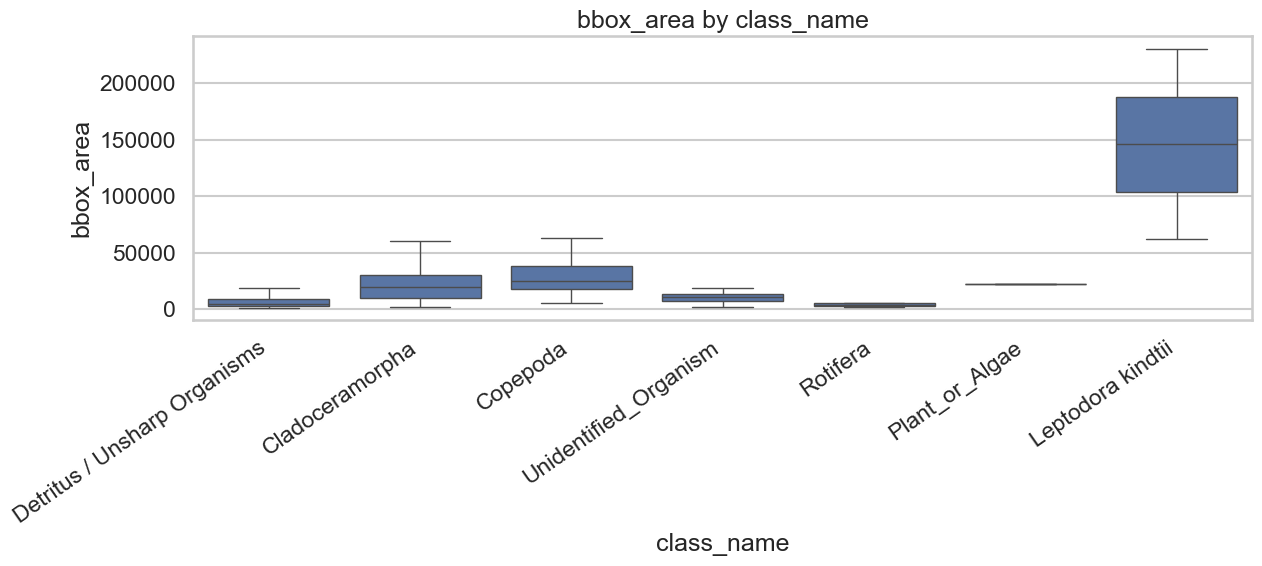

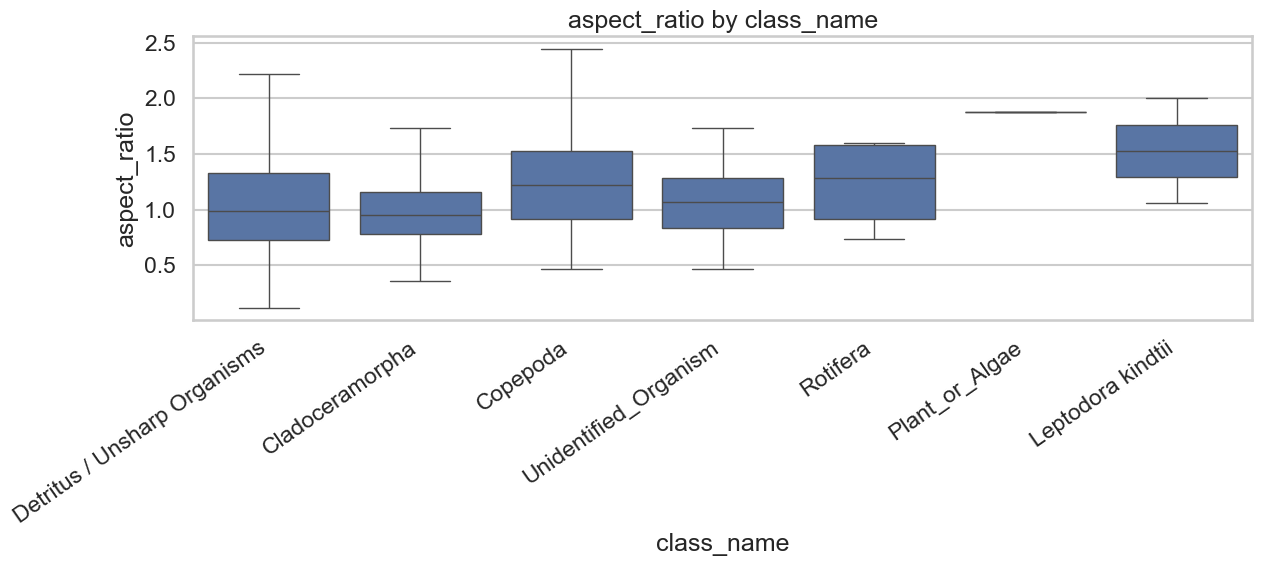

In [13]:
# 5) 形态特征 & bbox 尺寸分析

# 把类别信息并到 detections 上
merge_cols = ['detection_id', 'class_name', 'final_class', 'status', 'original_cluster']
df = df_det.merge(df_corr[merge_cols], left_on='object_id', right_on='detection_id', how='left')

df['bbox_area'] = df['w'] * df['h']
df['aspect_ratio'] = df['w'] / df['h'].replace(0, np.nan)

feature_cols = ['area', 'bbox_area', 'w', 'h', 'solidity', 'eccentricity', 'focus_score', 'quality_score', 'aspect_ratio']
display(df[feature_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# 每类样本太不均衡，箱线图更稳
for col in ['quality_score', 'solidity', 'eccentricity', 'focus_score']:
    plt.figure(figsize=(13, 6))
    sns.boxplot(data=df, x='class_name', y=col, showfliers=False)
    plt.xticks(rotation=35, ha='right')
    plt.title(f'{col} by class_name')
    plt.tight_layout()
    plt.show()

for col in ['w', 'h', 'bbox_area', 'aspect_ratio']:
    plt.figure(figsize=(13, 6))
    sns.boxplot(data=df, x='class_name', y=col, showfliers=False)
    plt.xticks(rotation=35, ha='right')
    plt.title(f'{col} by class_name')
    plt.tight_layout()
    plt.show()

,frame,n_detections,timestamp
count,200,200.00000,200
unique,200,NaN,NaN
top,RCNHSha_20250509_233918_IMG2,NaN,NaN
freq,1,NaN,NaN
mean,NaN,47.91500,2025-06-06 21:44:06.975000064
min,NaN,1.00000,2025-05-09 23:39:18
25%,NaN,21.75000,2025-05-12 03:01:43.500000
50%,NaN,44.00000,2025-05-14 05:39:47.500000
75%,NaN,71.25000,2025-05-16 04:09:27.500000
max,NaN,201.00000,2025-09-22 20:22:25


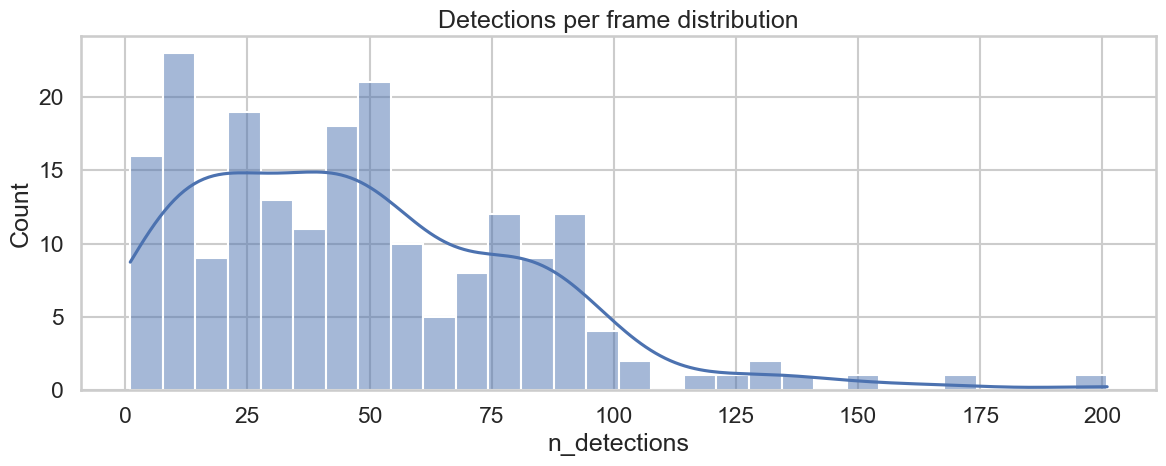

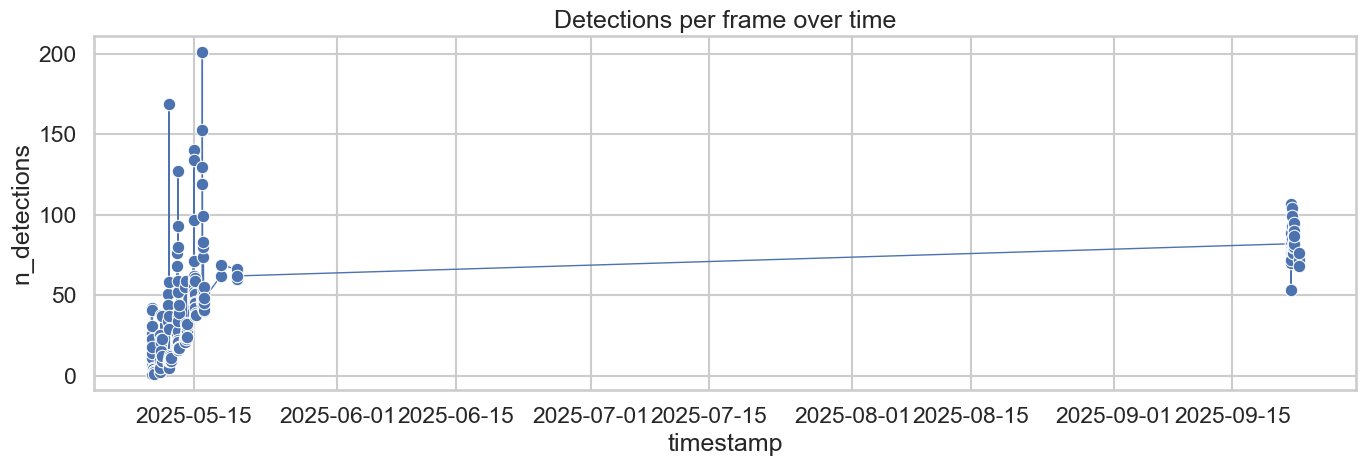

Total unique frames: 200
Mean detections per frame: 47.92
Median detections per frame: 44.0


In [14]:
# 6) 每帧检测数量 + 时间分布（从 frame 名解析时间戳）

frame_counts = df_corr.groupby('frame', as_index=False).size().rename(columns={'size': 'n_detections'})

# frame 示例: RCNHSha_20250509_233918_IMG2
pat = re.compile(r'.*_(\d{8})_(\d{6})_IMG\d+$')

def parse_ts(frame_name: str):
    m = pat.match(str(frame_name))
    if not m:
        return pd.NaT
    return pd.to_datetime(m.group(1) + m.group(2), format='%Y%m%d%H%M%S', errors='coerce')

frame_counts['timestamp'] = frame_counts['frame'].map(parse_ts)
frame_counts = frame_counts.sort_values('timestamp')

display(frame_counts.describe(include='all'))

plt.figure(figsize=(12, 5))
sns.histplot(frame_counts['n_detections'], bins=30, kde=True)
plt.title('Detections per frame distribution')
plt.tight_layout()
plt.show()

if frame_counts['timestamp'].notna().sum() > 0:
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=frame_counts, x='timestamp', y='n_detections', marker='o', linewidth=1)
    plt.title('Detections per frame over time')
    plt.tight_layout()
    plt.show()

print('Total unique frames:', frame_counts['frame'].nunique())
print('Mean detections per frame:', round(frame_counts['n_detections'].mean(), 2))
print('Median detections per frame:', round(frame_counts['n_detections'].median(), 2))

In [15]:
# 7) YOLO 导出一致性与数值质量检查

# 7.1 读取 classes / data.yaml 文本
if yolo_classes.exists():
    classes = [x.strip() for x in yolo_classes.read_text(encoding='utf-8').splitlines() if x.strip()]
    print('YOLO classes from classes.txt:', classes)

if yolo_yaml.exists():
    print('\n----- data.yaml -----')
    print(yolo_yaml.read_text(encoding='utf-8'))

# 7.2 汇总 labels/*.txt
label_files = sorted(yolo_labels_dir.glob('*.txt'))
print('YOLO label files:', len(label_files))

records = []
for lf in label_files:
    with open(lf, 'r', encoding='utf-8') as f:
        for ln, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                records.append({'file': lf.name, 'line': ln, 'parse_ok': False})
                continue
            cls, xc, yc, w, h = parts
            records.append({
                'file': lf.name,
                'line': ln,
                'parse_ok': True,
                'class_id': int(float(cls)),
                'x_center': float(xc),
                'y_center': float(yc),
                'width': float(w),
                'height': float(h),
            })

yolo_df = pd.DataFrame(records)
print('YOLO parsed rows:', len(yolo_df))
print('YOLO parse errors:', (~yolo_df['parse_ok']).sum() if 'parse_ok' in yolo_df.columns else 0)

if 'parse_ok' in yolo_df.columns:
    yolo_ok = yolo_df[yolo_df['parse_ok']].copy()
    print('\nCoordinate range (should usually be in [0,1] for normalized YOLO):')
    display(yolo_ok[['x_center', 'y_center', 'width', 'height']].agg(['min', 'max', 'mean']))

    out_of_range = (
        (yolo_ok['x_center'] < 0) | (yolo_ok['x_center'] > 1) |
        (yolo_ok['y_center'] < 0) | (yolo_ok['y_center'] > 1) |
        (yolo_ok['width'] <= 0) | (yolo_ok['width'] > 1) |
        (yolo_ok['height'] <= 0) | (yolo_ok['height'] > 1)
    )
    print('Out-of-range YOLO rows:', int(out_of_range.sum()), '/', len(yolo_ok))
    if out_of_range.sum() > 0:
        display(yolo_ok.loc[out_of_range].head(20))

# 7.3 与 corrected.csv 对比
print('\nCorrected rows:', len(df_corr))
print('YOLO parsed annotation rows:', len(yolo_df[yolo_df['parse_ok']]))

YOLO classes from classes.txt: ['Cladoceramorpha', 'Detritus / Unsharp Organisms', 'Copepoda', 'Unidentified_Organism', 'Plant_or_Algae', 'Rotifera', 'Leptodora kindtii']

----- data.yaml -----
# YOLO Dataset Configuration
# Generated by Shadowgraph Annotation Interface

path: .  # dataset root dir
train: images  # train images (relative to 'path')
val: images  # val images (relative to 'path')

# Classes
nc: 7  # number of classes
names: ['Cladoceramorpha', 'Detritus / Unsharp Organisms', 'Copepoda', 'Unidentified_Organism', 'Plant_or_Algae', 'Rotifera', 'Leptodora kindtii']

# Dataset info
# Total images with annotations: 200
# Total annotations: 9578
# Image size: 1920x1080

YOLO label files: 200
YOLO parsed rows: 9578
YOLO parse errors: 0

Coordinate range (should usually be in [0,1] for normalized YOLO):


,x_center,y_center,width,height
min,0.277344,0.105093,0.010937,0.022222
max,1.776823,2.741667,1.007292,0.657407
mean,1.038564,1.381034,0.045450,0.082477


Out-of-range YOLO rows: 8148 / 9578


,file,line,parse_ok,class_id,x_center,y_center,width,height
0,RCNHSha_20250509_233918_IMG2.txt,1,True,1,0.944271,2.323148,0.066667,0.077778
1,RCNHSha_20250509_233918_IMG2.txt,2,True,1,1.625000,1.775926,0.020833,0.044444
2,RCNHSha_20250509_233918_IMG2.txt,3,True,1,1.100000,2.681481,0.020833,0.061111
4,RCNHSha_20250509_233918_IMG2.txt,5,True,0,1.253646,2.193981,0.027083,0.052778
5,RCNHSha_20250509_233918_IMG2.txt,6,True,1,1.590885,1.578704,0.102604,0.127778
6,RCNHSha_20250509_233918_IMG2.txt,7,True,1,1.026302,0.766667,0.028646,0.057407
7,RCNHSha_20250509_233918_IMG2.txt,8,True,1,1.568750,0.901852,0.065625,0.096296
8,RCNHSha_20250509_233933_IMG3.txt,1,True,0,1.436198,0.766667,0.085938,0.146296
9,RCNHSha_20250509_233933_IMG3.txt,2,True,1,1.249219,1.488889,0.029687,0.075926
10,RCNHSha_20250509_233933_IMG3.txt,3,True,1,1.624740,1.765278,0.032813,0.036111



Corrected rows: 9583
YOLO parsed annotation rows: 9578


Subcluster groups found: 7


,sub_dir,parent_class,total_detections(run_json),n_subclusters,rows_detections_csv,rows_mosaic_csv,feature_dim
2,Detritus___Unsharp_Organisms_annotation,Detritus / Unsharp Organisms,9077,36,9077,9077,512
0,Cladoceramorpha_annotation,Cladoceramorpha,420,17,420,420,512
1,Copepoda_annotation,Copepoda,67,2,67,67,512
6,Unidentified_Organism_annotation,Unidentified_Organism,12,1,12,12,512
5,Rotifera_annotation,Rotifera,4,1,4,4,512
3,Leptodora_kindtii_annotation,Leptodora kindtii,2,1,2,2,512
4,Plant_or_Algae_annotation,Plant_or_Algae,1,1,1,1,512


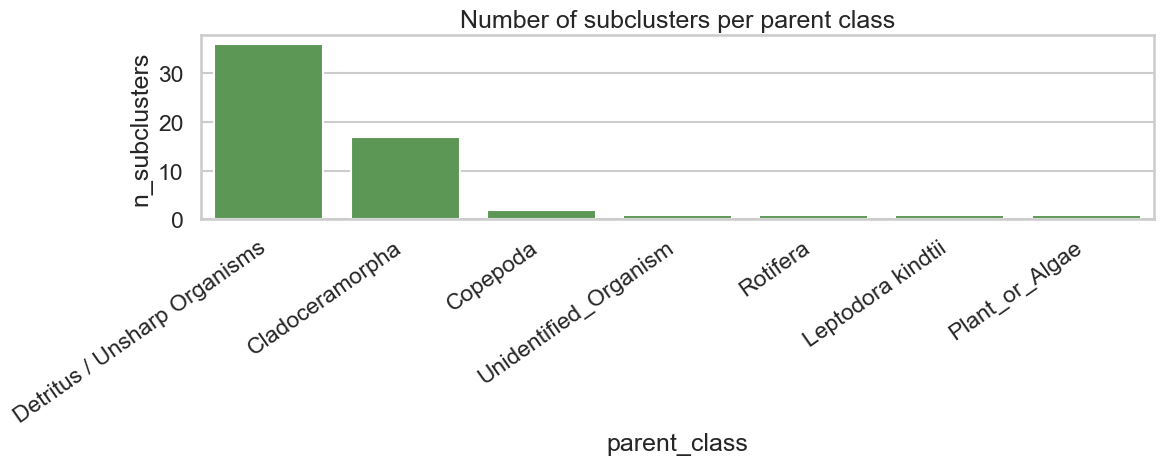

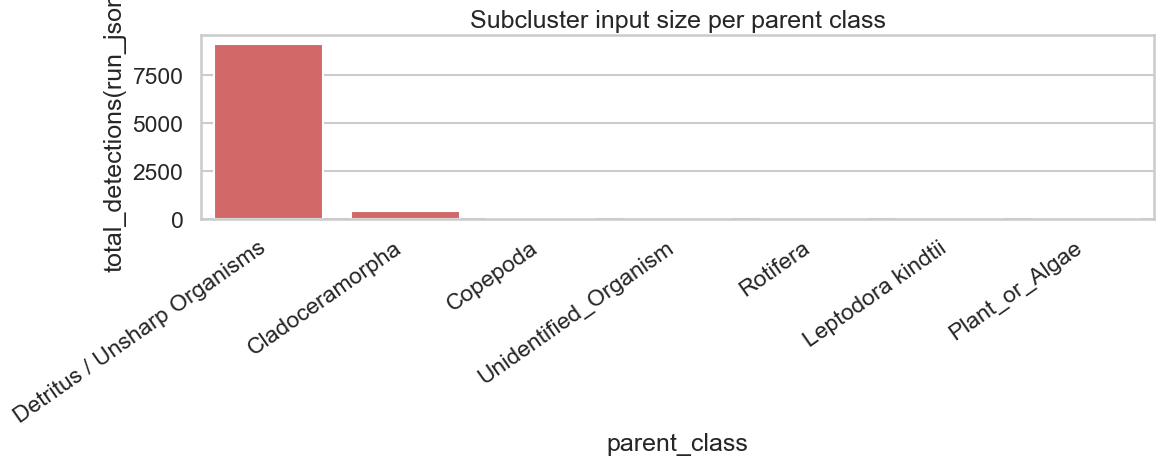

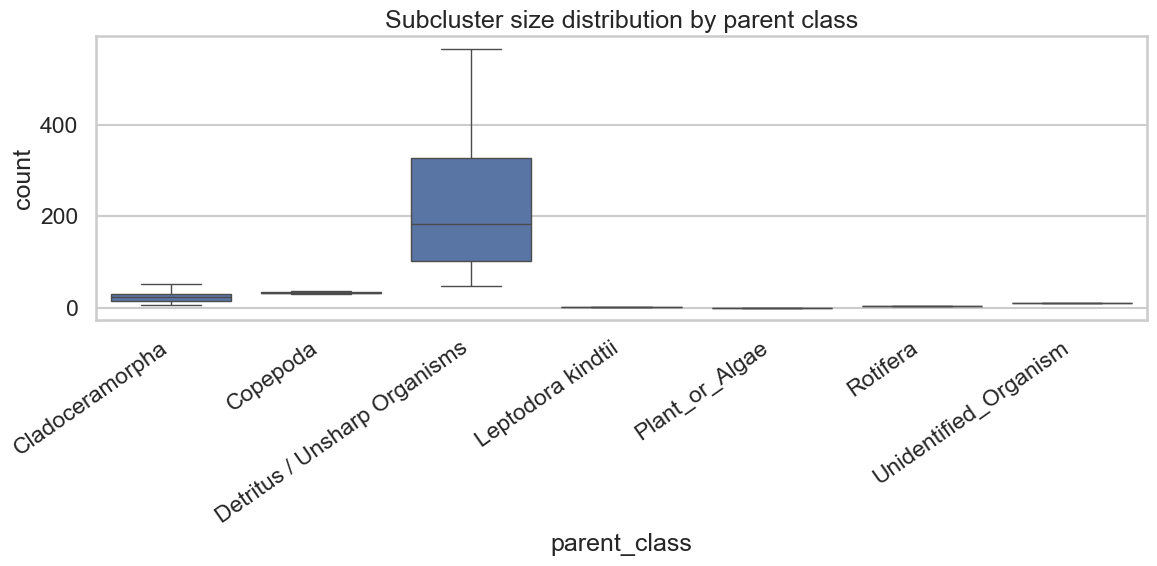

,parent_class,subcluster_id,count
3,Cladoceramorpha,3,53
5,Cladoceramorpha,5,41
7,Cladoceramorpha,7,40
6,Cladoceramorpha,6,37
1,Cladoceramorpha,1,31
8,Cladoceramorpha,8,31
2,Cladoceramorpha,2,27
4,Cladoceramorpha,4,25
0,Cladoceramorpha,0,24
9,Cladoceramorpha,9,21


In [16]:
# 8) subclusters 深度分析（DIR_B/subclusters 下所有类）

sub_root = DIR_B / 'subclusters'
sub_dirs = sorted([p for p in sub_root.iterdir() if p.is_dir()])

sub_summary_rows = []
sub_dist_rows = []

for sd in sub_dirs:
    rp = sd / 'run_parameters.json'
    dc = sd / 'detections.csv'
    mc = sd / 'mosaic_annotations.csv'

    with open(rp, 'r', encoding='utf-8') as f:
        rp_data = json.load(f)

    df_sub_det = pd.read_csv(dc)
    df_sub_mos = pd.read_csv(mc)

    parent_class = rp_data.get('parent_class')
    total_det = rp_data.get('results', {}).get('total_detections')
    n_subclusters = rp_data.get('results', {}).get('n_subclusters')

    sub_summary_rows.append({
        'sub_dir': sd.name,
        'parent_class': parent_class,
        'total_detections(run_json)': total_det,
        'n_subclusters': n_subclusters,
        'rows_detections_csv': len(df_sub_det),
        'rows_mosaic_csv': len(df_sub_mos),
        'feature_dim': rp_data.get('results', {}).get('feature_dim'),
    })

    dist = rp_data.get('cluster_distribution', {})
    for k, v in dist.items():
        sub_dist_rows.append({
            'parent_class': parent_class,
            'subcluster_id': int(k),
            'count': int(v)
        })

sub_summary = pd.DataFrame(sub_summary_rows).sort_values('total_detections(run_json)', ascending=False)
sub_dist = pd.DataFrame(sub_dist_rows)

print('Subcluster groups found:', len(sub_summary))
display(sub_summary)

plt.figure(figsize=(12, 5))
sns.barplot(data=sub_summary, x='parent_class', y='n_subclusters', color='#54A24B')
plt.xticks(rotation=35, ha='right')
plt.title('Number of subclusters per parent class')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=sub_summary, x='parent_class', y='total_detections(run_json)', color='#E45756')
plt.xticks(rotation=35, ha='right')
plt.title('Subcluster input size per parent class')
plt.tight_layout()
plt.show()

# 每个 parent_class 的子簇大小分布
if len(sub_dist) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=sub_dist, x='parent_class', y='count', showfliers=False)
    plt.xticks(rotation=35, ha='right')
    plt.title('Subcluster size distribution by parent class')
    plt.tight_layout()
    plt.show()

    display(sub_dist.sort_values(['parent_class', 'count'], ascending=[True, False]).head(50))

In [17]:
# 9) 关键结论自动汇总（会议可直接念）

majority_class = class_counts.iloc[0]['class_name']
majority_ratio = class_counts.iloc[0]['ratio_%']

report = pd.DataFrame([
    ('Unique frames', df_corr['frame'].nunique()),
    ('Total instances (corrected.csv)', len(df_corr)),
    ('Main class', majority_class),
    ('Main class ratio %', majority_ratio),
    ('Original cluster count (run_json)', run.get('results', {}).get('n_clusters')),
    ('Subcluster parent classes', len(sub_summary)),
    ('YOLO label files', len(label_files)),
    ('YOLO parsed rows', int(len(yolo_df[yolo_df['parse_ok']])) if 'parse_ok' in yolo_df.columns else np.nan),
], columns=['item', 'value'])

display(report)

print('\nModeling recommendations (for meeting):')
print('1) 强烈类别不均衡：必须使用 weighted loss / focal loss + per-class metrics。')
print('2) 划分训练/验证/测试时按 frame 划分，避免同图泄漏。')
print('3) 先做 7 类强基线，再尝试利用 subcluster 做类内细粒度或 supervised clustering。')
print('4) 若 YOLO 坐标有超范围样本，训练前先清洗或修正导出。')
print('5) 大量未标注新图建议用于自监督预训练，再在200图标注上微调。')

,item,value
0,Unique frames,200
1,Total instances (corrected.csv),9583
2,Main class,Detritus / Unsharp Organisms
3,Main class ratio %,94.72
4,Original cluster count (run_json),49
5,Subcluster parent classes,7
6,YOLO label files,200
7,YOLO parsed rows,9578



Modeling recommendations (for meeting):
1) 强烈类别不均衡：必须使用 weighted loss / focal loss + per-class metrics。
2) 划分训练/验证/测试时按 frame 划分，避免同图泄漏。
3) 先做 7 类强基线，再尝试利用 subcluster 做类内细粒度或 supervised clustering。
4) 若 YOLO 坐标有超范围样本，训练前先清洗或修正导出。
5) 大量未标注新图建议用于自监督预训练，再在200图标注上微调。
